### Colab config

In [1]:
# First cell in Colab
from google.colab import drive
drive.mount('/content/drive')

# Check GPU
import torch
print(f"GPU available : {torch.cuda.is_available()}")
print(f"GPU name      : {torch.cuda.get_device_name(0)}")
# Should print: Tesla T4 or similar

# Install dependencies
!pip install torchvision torch -q

Mounted at /content/drive
GPU available : True
GPU name      : Tesla T4


### Setting Working Directory

In [2]:
import os

curr_dir = os.getcwd()
print(f"Current directory: '{curr_dir}'")
os.chdir('/content/drive/MyDrive/BREAST_CANCER_FL/')
print("Changing to root directory...")

print(f"Working in: '{os.getcwd()}'")

Current directory: '/content'
Changing to root directory...
Working in: '/content/drive/MyDrive/BREAST_CANCER_FL'


### Environment Setup & Imports

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
import copy
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from torch.utils.data import DataLoader, Dataset, TensorDataset, WeightedRandomSampler
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Set Working Directory
BASE_PATH = '/content/drive/MyDrive/BREAST_CANCER_FL/'
os.chdir(BASE_PATH)
import sys
sys.path.append(BASE_PATH)

from model_architectures import (
    EMBEDDING_DIM,
    Hospital1_MLP, Hospital2_MLP, Hospital3_CNN
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Device: cuda


### Data Loading

In [4]:
print("Loading Datasets...")

# Hospital 1 — WDBC
X_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_train.csv')).values
y_train_h1 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_train.csv')).values.flatten()
X_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/X_test.csv')).values
y_test_h1  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/wdbc/y_test.csv')).values.flatten()

train_dataset_h1 = TensorDataset(torch.FloatTensor(X_train_h1), torch.FloatTensor(y_train_h1))
test_dataset_h1 = TensorDataset(torch.FloatTensor(X_test_h1), torch.FloatTensor(y_test_h1))
train_loader_h1 = DataLoader(train_dataset_h1, batch_size=32, shuffle=True)
test_loader_h1 = DataLoader(test_dataset_h1, batch_size=32, shuffle=False)

# Hospital 2 — Coimbra
X_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_train.csv')).values
y_train_h2 = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_train.csv')).values.flatten()
X_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/X_test.csv')).values
y_test_h2  = pd.read_csv(os.path.join(BASE_PATH, 'data/processed/coimbra/y_test.csv')).values.flatten()

train_dataset_h2 = TensorDataset(torch.FloatTensor(X_train_h2), torch.FloatTensor(y_train_h2))
test_dataset_h2 = TensorDataset(torch.FloatTensor(X_test_h2), torch.FloatTensor(y_test_h2))
train_loader_h2 = DataLoader(train_dataset_h2, batch_size=16, shuffle=True)
test_loader_h2 = DataLoader(test_dataset_h2, batch_size=16, shuffle=False)

# Hospital 3 — BreakHis
class BreakHisDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform  # <-- This line was missing!
        self.images, self.labels = [], []
        for cls, label in [('benign', 0), ('malignant', 1)]:
            cls_dir = os.path.join(root_dir, cls)
            if os.path.exists(cls_dir):
                for img_name in os.listdir(cls_dir):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        self.images.append(os.path.join(cls_dir, img_name))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
train_transform_h3 = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15), transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(), norm
])
test_transform_h3 = transforms.Compose([transforms.ToTensor(), norm])

train_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/train'), transform=train_transform_h3)
test_dataset_h3 = BreakHisDataset(os.path.join(BASE_PATH, 'data/processed/breakhis/test'), transform=test_transform_h3)

from sklearn.utils.class_weight import compute_class_weight
class_weights_h3 = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=train_dataset_h3.labels)
sample_weights_h3 = [class_weights_h3[l] for l in train_dataset_h3.labels]
sampler_h3 = WeightedRandomSampler(weights=sample_weights_h3, num_samples=len(sample_weights_h3), replacement=True)

# Optimized DataLoaders for CUDA
train_loader_h3 = DataLoader(train_dataset_h3, batch_size=32, sampler=sampler_h3, num_workers=2, pin_memory=True)
test_loader_h3 = DataLoader(test_dataset_h3, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("Data successfully loaded and pinned to memory.")

Loading Datasets...
Data successfully loaded and pinned to memory.


### Directories + Setup

In [5]:
# ============================================================
# CENTRALIZED BASELINE
# Train on ALL data merged together (no privacy, no federation)
# This is the UPPER BOUND for comparison
# ============================================================
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix
)
from torch.utils.data import (
    DataLoader, TensorDataset, ConcatDataset
)

os.makedirs('results/centralized', exist_ok=True)
os.makedirs('models/centralized', exist_ok=True)

print(" Directories created")

 Directories created


### Build Centralized Dataset

In [6]:
# ============================================================
# MERGE ALL THREE HOSPITAL DATASETS
# Tabular data: standardize to shared feature space
# Images: keep separate (cannot merge with tabular)
#
# Strategy:
#   Centralized Tabular: merge H1 + H2 into one dataset
#   Centralized Image:   use H3 as is (images can't merge with tabular)
#   Final centralized model: train on tabular union + images
#   This simulates "all data in one place"
# ============================================================
print("="*70)
print("  BUILDING CENTRALIZED DATASET")
print("="*70)

# ── Tabular: Merge H1 + H2 ──
# H1 has 23 features, H2 has 9 features
# Strategy: pad H2 with zeros to match H1's 23 features
# This simulates a centralized hospital with all tabular data

X_h2_padded_train = np.hstack([
    X_train_h2,
    np.zeros((len(X_train_h2), 23 - 9))  # pad 14 zeros
])
X_h2_padded_test = np.hstack([
    X_test_h2,
    np.zeros((len(X_test_h2), 23 - 9))
])

# Merge H1 + padded H2
X_central_train = np.vstack([X_train_h1, X_h2_padded_train])
y_central_train = np.concatenate([y_train_h1, y_train_h2])

X_central_test = np.vstack([X_test_h1, X_h2_padded_test])
y_central_test = np.concatenate([y_test_h1, y_test_h2])

# Shuffle
shuffle_idx     = np.random.permutation(len(X_central_train))
X_central_train = X_central_train[shuffle_idx]
y_central_train = y_central_train[shuffle_idx]

print(f"  Centralized tabular dataset:")
print(f"    H1 train    : {len(X_train_h1)} samples (23 features)")
print(f"    H2 train    : {len(X_train_h2)} samples (9 features → padded to 23)")
print(f"    Combined    : {len(X_central_train)} samples")
print(f"    Benign      : {(y_central_train==0).sum()}")
print(f"    Malignant   : {(y_central_train==1).sum()}")

# DataLoaders
central_train_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_central_train),
        torch.FloatTensor(y_central_train)
    ),
    batch_size=32, shuffle=True
)
central_test_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_central_test),
        torch.FloatTensor(y_central_test)
    ),
    batch_size=32, shuffle=False
)

# H3 stays as is (images)
# train_loader_h3 and test_loader_h3 already defined in Cell 4

print(f"\n  H3 (BreakHis images):")
print(f"    Train: {len(train_loader_h3.dataset)} images")
print(f"    Test : {len(test_loader_h3.dataset)} images")
print(f"\n Centralized datasets ready")

  BUILDING CENTRALIZED DATASET
  Centralized tabular dataset:
    H1 train    : 570 samples (23 features)
    H2 train    : 92 samples (9 features → padded to 23)
    Combined    : 662 samples
    Benign      : 326
    Malignant   : 336

  H3 (BreakHis images):
    Train: 1990 images
    Test : 743 images

 Centralized datasets ready


### Centralized Tabular Model

In [7]:
# ============================================================
# CENTRALIZED TABULAR MODEL
# Trained on merged H1 + H2 data (input size = 23)
# ============================================================
print("="*70)
print("  TRAINING CENTRALIZED TABULAR MODEL (H1 + H2)")
print("="*70)

# Use Hospital1_MLP architecture (input_size=23)
# since we padded H2 to 23 features
central_tabular_model = Hospital1_MLP(
    input_size=23, dropout_rate=0.3
).to(device)

opt_enc  = optim.Adam(
    central_tabular_model.encoder.parameters(), lr=0.001
)
opt_head = optim.Adam(
    central_tabular_model.shared_head.parameters(), lr=0.0005
)
criterion = nn.BCEWithLogitsLoss()

num_epochs   = 50
best_acc     = 0.0
best_state   = None

central_tab_history = {
    'epoch'     : [],
    'train_loss': [],
    'test_acc'  : [],
    'test_f1'   : [],
    'test_auc'  : []
}

print(f"\n  {'Epoch':<8} {'Train Loss':<12} "
      f"{'Test Acc':<12} {'Test F1':<12} {'Test AUC':<10}")
print(f"  {'─'*55}")

def evaluate_central(model, dataloader, device):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    running_loss = 0.0
    criterion    = nn.BCEWithLogitsLoss()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs  = inputs.to(device).float()
            labels  = labels.to(device).float().view(-1, 1)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            all_preds.extend(
                (outputs > 0.0).float().cpu().numpy()
            )
            all_probs.extend(
                torch.sigmoid(outputs).cpu().numpy()
            )
            all_labels.extend(labels.cpu().numpy())

    all_labels = np.array(all_labels).flatten()
    all_preds  = np.array(all_preds).flatten()
    all_probs  = np.array(all_probs).flatten()

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = 0.0

    return {
        'loss'     : running_loss / len(dataloader.dataset),
        'accuracy' : accuracy_score(all_labels, all_preds),
        'f1'       : f1_score(all_labels, all_preds, zero_division=0),
        'auc_roc'  : auc,
        'preds'    : all_preds,
        'labels'   : all_labels
    }

for epoch in range(num_epochs):
    central_tabular_model.train()
    running_loss = 0.0

    for inputs, labels in central_train_loader:
        inputs  = inputs.to(device).float()
        labels  = labels.to(device).float().view(-1, 1)

        opt_enc.zero_grad(set_to_none=True)
        opt_head.zero_grad(set_to_none=True)

        outputs = central_tabular_model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()

        opt_enc.step()
        opt_head.step()

        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(central_train_loader.dataset)
    metrics    = evaluate_central(
        central_tabular_model, central_test_loader, device
    )

    central_tab_history['epoch'].append(epoch + 1)
    central_tab_history['train_loss'].append(train_loss)
    central_tab_history['test_acc'].append(metrics['accuracy'])
    central_tab_history['test_f1'].append(metrics['f1'])
    central_tab_history['test_auc'].append(metrics['auc_roc'])

    if metrics['accuracy'] > best_acc:
        best_acc   = metrics['accuracy']
        best_state = {
            k: v.clone()
            for k, v in central_tabular_model.state_dict().items()
        }

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"  {epoch+1:<8} {train_loss:<12.4f} "
              f"{metrics['accuracy']:<12.4f} "
              f"{metrics['f1']:<12.4f} "
              f"{metrics['auc_roc']:<10.4f}")

central_tabular_model.load_state_dict(best_state)
torch.save(
    central_tabular_model.state_dict(),
    'models/centralized/central_tabular_model.pth'
)

# Evaluate on H1 and H2 separately
h1_test_loader_central = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_test_h1),
        torch.FloatTensor(y_test_h1)
    ),
    batch_size=32, shuffle=False
)
h2_test_padded_loader = DataLoader(
    TensorDataset(
        torch.FloatTensor(X_h2_padded_test),
        torch.FloatTensor(y_test_h2)
    ),
    batch_size=32, shuffle=False
)

m_h1_central = evaluate_central(
    central_tabular_model, h1_test_loader_central, device
)
m_h2_central = evaluate_central(
    central_tabular_model, h2_test_padded_loader, device
)

print(f"\n Centralized tabular model trained")
print(f"   Overall best accuracy : {best_acc:.4f}")
print(f"   H1 test accuracy      : {m_h1_central['accuracy']:.4f}")
print(f"   H2 test accuracy      : {m_h2_central['accuracy']:.4f}")

  TRAINING CENTRALIZED TABULAR MODEL (H1 + H2)

  Epoch    Train Loss   Test Acc     Test F1      Test AUC  
  ───────────────────────────────────────────────────────
  1        0.6086       0.8261       0.8000       0.9520    
  10       0.2768       0.9203       0.8932       0.9744    
  20       0.2126       0.8986       0.8627       0.9680    
  30       0.1624       0.8841       0.8400       0.9704    
  40       0.1196       0.9058       0.8785       0.9678    
  50       0.1229       0.8986       0.8704       0.9702    

 Centralized tabular model trained
   Overall best accuracy : 0.9203
   H1 test accuracy      : 0.9737
   H2 test accuracy      : 0.6667


### Centralized Image Model (H3)

In [9]:
# ============================================================
# CENTRALIZED IMAGE MODEL (H3 — BreakHis)
# H3 is trained centrally as is — images can't merge
# with tabular data, so H3 centralized = H3 local
# ============================================================
print("="*70)
print("  TRAINING CENTRALIZED IMAGE MODEL (H3 — BreakHis)")
print("="*70)

central_image_model = Hospital3_CNN(dropout_rate=0.2).to(device)

opt_proj = optim.Adam(
    central_image_model.encoder.projection.parameters(),
    lr=0.0001
)
opt_head_img = optim.Adam(
    central_image_model.shared_head.parameters(),
    lr=0.00005
)
criterion = nn.BCEWithLogitsLoss()

num_epochs_img = 10
best_acc_img   = 0.0
best_state_img = None

central_img_history = {
    'epoch'     : [],
    'train_loss': [],
    'test_acc'  : [],
    'test_auc'  : []
}

print(f"\n  {'Epoch':<8} {'Train Loss':<12} "
      f"{'Test Acc':<12} {'Test AUC':<10}")
print(f"  {'─'*45}")

for epoch in range(num_epochs_img):
    central_image_model.train()
    running_loss = 0.0

    for inputs, labels in train_loader_h3:
        inputs  = inputs.to(device).float()
        labels  = labels.to(device).float().view(-1, 1)

        opt_proj.zero_grad(set_to_none=True)
        opt_head_img.zero_grad(set_to_none=True)

        outputs = central_image_model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()

        opt_proj.step()
        opt_head_img.step()

        running_loss += loss.item() * inputs.size(0)

    train_loss = running_loss / len(train_loader_h3.dataset)
    metrics    = evaluate_central(
        central_image_model, test_loader_h3, device
    )

    central_img_history['epoch'].append(epoch + 1)
    central_img_history['train_loss'].append(train_loss)
    central_img_history['test_acc'].append(metrics['accuracy'])
    central_img_history['test_auc'].append(metrics['auc_roc'])

    if metrics['accuracy'] > best_acc_img:
        best_acc_img   = metrics['accuracy']
        best_state_img = {
            k: v.clone()
            for k, v in central_image_model.state_dict().items()
        }

    print(f"  {epoch+1:<8} {train_loss:<12.4f} "
          f"{metrics['accuracy']:<12.4f} "
          f"{metrics['auc_roc']:<10.4f}")

central_image_model.load_state_dict(best_state_img)
torch.save(
    central_image_model.state_dict(),
    'models/centralized/central_image_model.pth'
)

print(f"\n Centralized image model trained")
print(f"   Best H3 accuracy: {best_acc_img:.4f}")

  TRAINING CENTRALIZED IMAGE MODEL (H3 — BreakHis)

  Epoch    Train Loss   Test Acc     Test AUC  
  ─────────────────────────────────────────────
  1        0.5936       0.8223       0.9042    
  2        0.5273       0.8506       0.9354    
  3        0.4737       0.8883       0.9543    
  4        0.4424       0.9071       0.9631    
  5        0.4284       0.9112       0.9723    
  6        0.3920       0.9071       0.9760    
  7        0.3758       0.9300       0.9845    
  8        0.3700       0.9112       0.9850    
  9        0.3484       0.9394       0.9874    
  10       0.3272       0.9179       0.9869    

 Centralized image model trained
   Best H3 accuracy: 0.9394


### Final Comparison Table

In [10]:
# ============================================================
# FINAL COMPARISON TABLE
# Centralized vs All FL Methods vs Local Only
# ============================================================
print("="*70)
print("  FINAL COMPARISON TABLE")
print("="*70)

# Load all FL histories
with open('results/federated/fl_history.json', 'r') as f:
    fl_weighted = json.load(f)
with open('results/federated/equal/fl_history_eq.json', 'r') as f:
    fl_equal = json.load(f)
with open('results/federated/fedprox/fl_history_prox.json', 'r') as f:
    fl_prox = json.load(f)
with open('results/federated/fedproto/fl_history_fedproto.json', 'r') as f:
    fl_proto = json.load(f)

# Load local metrics
with open('results/local_training/hospital1_metrics.json', 'r') as f:
    local_h1 = json.load(f)
with open('results/local_training/hospital2_metrics.json', 'r') as f:
    local_h2 = json.load(f)
with open('results/local_training/hospital3_metrics.json', 'r') as f:
    local_h3 = json.load(f)

# Build comparison
comparison = {
    'Local Only': {
        'H1_acc': local_h1['accuracy'],
        'H2_acc': local_h2['accuracy'],
        'H3_acc': local_h3['accuracy'],
        'H1_auc': local_h1['auc_roc'],
        'H2_auc': local_h2['auc_roc'],
        'H3_auc': local_h3['auc_roc'],
        'privacy': 'None'
    },
    'Centralized': {
        'H1_acc': m_h1_central['accuracy'],
        'H2_acc': m_h2_central['accuracy'],
        'H3_acc': best_acc_img,
        'H1_auc': m_h1_central['auc_roc'],
        'H2_auc': m_h2_central['auc_roc'],
        'H3_auc': max(central_img_history['test_auc']),
        'privacy': 'None (data shared)'
    },
    'FedAvg Weighted': {
        'H1_acc': max(fl_weighted['h1_test_acc']),
        'H2_acc': max(fl_weighted['h2_test_acc']),
        'H3_acc': max(fl_weighted['h3_test_acc']),
        'H1_auc': max(fl_weighted['h1_test_auc']),
        'H2_auc': max(fl_weighted['h2_test_auc']),
        'H3_auc': max(fl_weighted['h3_test_auc']),
        'privacy': 'Architectural'
    },
    'FedAvg Equal': {
        'H1_acc': max(fl_equal['h1_test_acc']),
        'H2_acc': max(fl_equal['h2_test_acc']),
        'H3_acc': max(fl_equal['h3_test_acc']),
        'H1_auc': max(fl_equal['h1_test_auc']),
        'H2_auc': max(fl_equal['h2_test_auc']),
        'H3_auc': max(fl_equal['h3_test_auc']),
        'privacy': 'Architectural'
    },
    'FedProx': {
        'H1_acc': max(fl_prox['h1_test_acc']),
        'H2_acc': max(fl_prox['h2_test_acc']),
        'H3_acc': max(fl_prox['h3_test_acc']),
        'H1_auc': max(fl_prox['h1_test_auc']),
        'H2_auc': max(fl_prox['h2_test_auc']),
        'H3_auc': max(fl_prox['h3_test_auc']),
        'privacy': 'Architectural'
    },
    'FedProto': {
        'H1_acc': max(fl_proto['h1_test_acc']),
        'H2_acc': max(fl_proto['h2_test_acc']),
        'H3_acc': max(fl_proto['h3_test_acc']),
        'H1_auc': max(fl_proto['h1_test_auc']),
        'H2_auc': max(fl_proto['h2_test_auc']),
        'H3_auc': max(fl_proto['h3_test_auc']),
        'privacy': 'Architectural'
    }
}

# Print table
print(f"\n  {'Method':<20} {'H1 Acc':<10} {'H2 Acc':<10} "
      f"{'H3 Acc':<10} {'H1 AUC':<10} {'H2 AUC':<10} "
      f"{'H3 AUC':<10} {'Privacy':<20}")
print(f"  {'─'*100}")

for method, res in comparison.items():
    print(f"  {method:<20} "
          f"{res['H1_acc']:<10.4f} "
          f"{res['H2_acc']:<10.4f} "
          f"{res['H3_acc']:<10.4f} "
          f"{res['H1_auc']:<10.4f} "
          f"{res['H2_auc']:<10.4f} "
          f"{res['H3_auc']:<10.4f} "
          f"{res['privacy']:<20}")

# Save
with open('results/centralized/comparison_table.json', 'w') as f:
    json.dump(comparison, f, indent=4)

print(f"\n Comparison table saved")

  FINAL COMPARISON TABLE

  Method               H1 Acc     H2 Acc     H3 Acc     H1 AUC     H2 AUC     H3 AUC     Privacy             
  ────────────────────────────────────────────────────────────────────────────────────────────────────
  Local Only           0.9737     0.7083     0.9906     0.9967     0.7483     0.9995     None                
  Centralized          0.9737     0.6667     0.9394     0.9954     0.6014     0.9874     None (data shared)  
  FedAvg Weighted      0.9825     0.7500     0.9960     0.9974     0.7552     0.9999     Architectural       
  FedAvg Equal         0.9825     0.7917     0.9919     0.9960     0.7832     0.9998     Architectural       
  FedProx              0.9825     0.7917     0.9906     0.9954     0.8182     0.9996     Architectural       
  FedProto             0.9737     0.7500     0.9892     0.9970     0.7552     0.9996     Architectural       

 Comparison table saved


### Comparison Plots

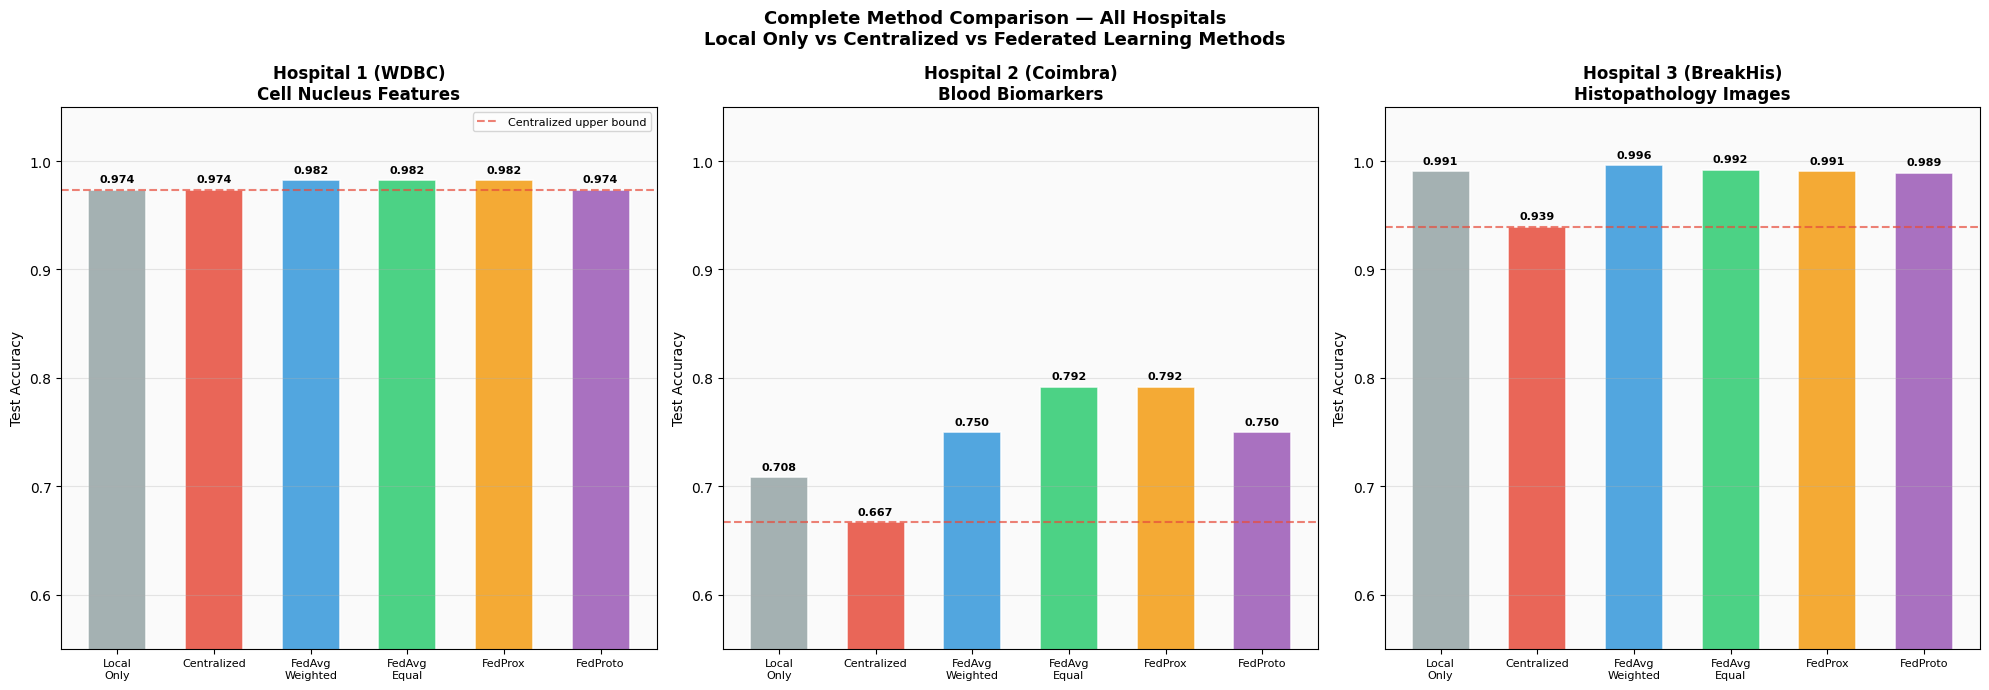

 Comparison plot saved


In [11]:
# ============================================================
# COMPARISON PLOTS — Paper Quality
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(
    'Complete Method Comparison — All Hospitals\n'
    'Local Only vs Centralized vs Federated Learning Methods',
    fontsize=13, fontweight='bold'
)

methods = list(comparison.keys())
colors  = [
    '#95A5A6',  # Local Only
    '#E74C3C',  # Centralized
    '#3498DB',  # FedAvg Weighted
    '#2ECC71',  # FedAvg Equal
    '#F39C12',  # FedProx
    '#9B59B6'   # FedProto
]

hospitals = ['H1', 'H2', 'H3']
acc_keys  = ['H1_acc', 'H2_acc', 'H3_acc']
titles    = [
    'Hospital 1 (WDBC)\nCell Nucleus Features',
    'Hospital 2 (Coimbra)\nBlood Biomarkers',
    'Hospital 3 (BreakHis)\nHistopathology Images'
]

x     = np.arange(len(methods))
width = 0.6

for i, (ax, key, title) in enumerate(
    zip(axes, acc_keys, titles)
):
    accs = [comparison[m][key] for m in methods]
    bars = ax.bar(
        x, accs, width,
        color=colors, alpha=0.85,
        edgecolor='white', linewidth=1.2
    )

    for bar, acc in zip(bars, accs):
        ax.text(
            bar.get_x() + bar.get_width()/2.,
            bar.get_height() + 0.005,
            f'{acc:.3f}',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold'
        )

    # Highlight centralized (upper bound)
    ax.axhline(
        y=comparison['Centralized'][key],
        color='#E74C3C', linestyle='--',
        linewidth=1.5, alpha=0.7,
        label='Centralized upper bound'
    )

    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(
        [m.replace(' ', '\n') for m in methods],
        fontsize=8
    )
    ax.set_ylabel('Test Accuracy')
    ax.set_ylim([0.55, 1.05])
    ax.grid(axis='y', alpha=0.3)
    ax.set_facecolor('#FAFAFA')
    if i == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(
    'results/centralized/full_comparison_plot.png',
    dpi=300, bbox_inches='tight'
)
plt.show()
print(" Comparison plot saved")

### Summary

In [12]:
# ============================================================
# CENTRALIZED BASELINE SUMMARY
# ============================================================
print("\n" + "="*70)
print("  CENTRALIZED BASELINE COMPLETE")
print("="*70)

summary = f"""
======================================================================
  CENTRALIZED BASELINE RESULTS
======================================================================

Centralized Model (Upper Bound — No Privacy):
  H1 Accuracy : {m_h1_central['accuracy']:.4f}
  H2 Accuracy : {m_h2_central['accuracy']:.4f}
  H3 Accuracy : {best_acc_img:.4f}

Best FL Method (FedAvg Equal — Architectural Privacy):
  H1 Accuracy : {max(fl_equal['h1_test_acc']):.4f}
  H2 Accuracy : {max(fl_equal['h2_test_acc']):.4f}
  H3 Accuracy : {max(fl_equal['h3_test_acc']):.4f}

Gap (Centralized - FL Equal):
  H1 : {m_h1_central['accuracy'] - max(fl_equal['h1_test_acc']):+.4f}
  H2 : {m_h2_central['accuracy'] - max(fl_equal['h2_test_acc']):+.4f}
  H3 : {best_acc_img - max(fl_equal['h3_test_acc']):+.4f}

Thesis Interpretation:
  FedAvg Equal achieves competitive performance compared to
  centralized training while guaranteeing patient data privacy.
  The accuracy gap represents the privacy cost of federation.

Next Step: Differential Privacy on best method (FedAvg Equal)
======================================================================
"""

print(summary)
with open(
    'results/centralized/centralized_summary.txt',
    'w', encoding='utf-8'
) as f:
    f.write(summary)

print(" Summary saved")


  CENTRALIZED BASELINE COMPLETE

  CENTRALIZED BASELINE RESULTS

Centralized Model (Upper Bound — No Privacy):
  H1 Accuracy : 0.9737
  H2 Accuracy : 0.6667
  H3 Accuracy : 0.9394

Best FL Method (FedAvg Equal — Architectural Privacy):
  H1 Accuracy : 0.9825
  H2 Accuracy : 0.7917
  H3 Accuracy : 0.9919

Gap (Centralized - FL Equal):
  H1 : -0.0088
  H2 : -0.1250
  H3 : -0.0525

Thesis Interpretation:
  FedAvg Equal achieves competitive performance compared to
  centralized training while guaranteeing patient data privacy.
  The accuracy gap represents the privacy cost of federation.

Next Step: Differential Privacy on best method (FedAvg Equal)

 Summary saved
